Cell 1 — Imports and load data:

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=True)

# Load the QC-filtered data from Program 2
adata = sc.read_h5ad(os.path.expanduser("~/ATRT/Data/adata_QC_filtered.h5ad"))
print(f"Loaded: {adata.n_obs} nuclei x {adata.n_vars} genes")
print(f"Samples: {adata.obs['sample'].nunique()}")
print(f"Subgroups: {adata.obs['subgroup'].unique().tolist()}")

Loaded: 9604 nuclei x 36601 genes
Samples: 7
Subgroups: ['ATRT-SHH', 'ATRT-MYC', 'ATRT-TYR']


Cell 2 — Store raw counts (important for later DE analysis):

In [2]:
# Store raw counts in adata.raw so we can access them later
# for differential expression and ZMYM3 visualization
adata.raw = adata.copy()
print("Raw counts stored in adata.raw")
print(f"  adata.raw: {adata.raw.n_obs} nuclei x {adata.raw.n_vars} genes")

Raw counts stored in adata.raw
  adata.raw: 9604 nuclei x 36601 genes


Cell 3 — Normalize (CP10K + log1p):

In [3]:
# Normalize to 10,000 counts per nucleus (CP10K)
sc.pp.normalize_total(adata, target_sum=1e4)
print("CP10K normalization complete")

# Log-transform
sc.pp.log1p(adata)
print("Log1p transformation complete")

# ============================================================
# REPORT NOTE: "Counts were normalized to 10,000 counts per 
# nucleus (CP10K)... followed by log1p transformation."
# ============================================================

# Quick check on ZMYM3
if 'ZMYM3' in adata.var_names:
    zmym3_expr = adata[:, 'ZMYM3'].X.toarray().flatten() if hasattr(adata[:, 'ZMYM3'].X, 'toarray') else adata[:, 'ZMYM3'].X.flatten()
    pct_expressing = (zmym3_expr > 0).sum() / len(zmym3_expr) * 100
    print(f"\n>>> ZMYM3 CHECK:")
    print(f">>> {pct_expressing:.1f}% of nuclei express ZMYM3")
    print(f">>> Mean normalized expression: {zmym3_expr.mean():.4f}")
    print(f">>> Max normalized expression: {zmym3_expr.max():.4f}")
else:
    print("\n>>> WARNING: ZMYM3 not found in gene names!")
    # Check for close matches
    matches = [g for g in adata.var_names if 'ZMYM' in g.upper()]
    print(f">>> Genes containing 'ZMYM': {matches}")

normalizing counts per cell
    finished (0:00:00)
CP10K normalization complete
Log1p transformation complete

>>> ZMYM3 CHECK:
>>> 8.9% of nuclei express ZMYM3
>>> Mean normalized expression: 0.1201
>>> Max normalized expression: 2.9143


Cell 4 — Identify highly variable genes (HVGs):

In [4]:
# Identify top 2,000 HVGs using Seurat method (mean-dispersion binning)
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=2000)

n_hvg = adata.var['highly_variable'].sum()
print(f"Highly variable genes selected: {n_hvg}")

# ============================================================
# REPORT VALUE: Is ZMYM3 among the HVGs?
# (Note: ZMYM3 does NOT need to be an HVG for our analysis —
#  we evaluate it in the full normalized matrix regardless)
# ============================================================
if 'ZMYM3' in adata.var_names:
    zmym3_hvg = adata.var.loc['ZMYM3', 'highly_variable']
    print(f"\n>>> ZMYM3 is {'IN' if zmym3_hvg else 'NOT in'} the top 2,000 HVGs")
    print(f">>> (This is expected — ZMYM3 expression is evaluated from the")
    print(f">>>  full normalized matrix, not the HVG subset)")

extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Highly variable genes selected: 2000

>>> ZMYM3 is NOT in the top 2,000 HVGs
>>> (This is expected — ZMYM3 expression is evaluated from the
>>>  full normalized matrix, not the HVG subset)


Cell 5 — Plot HVG dispersion (supplementary figure):

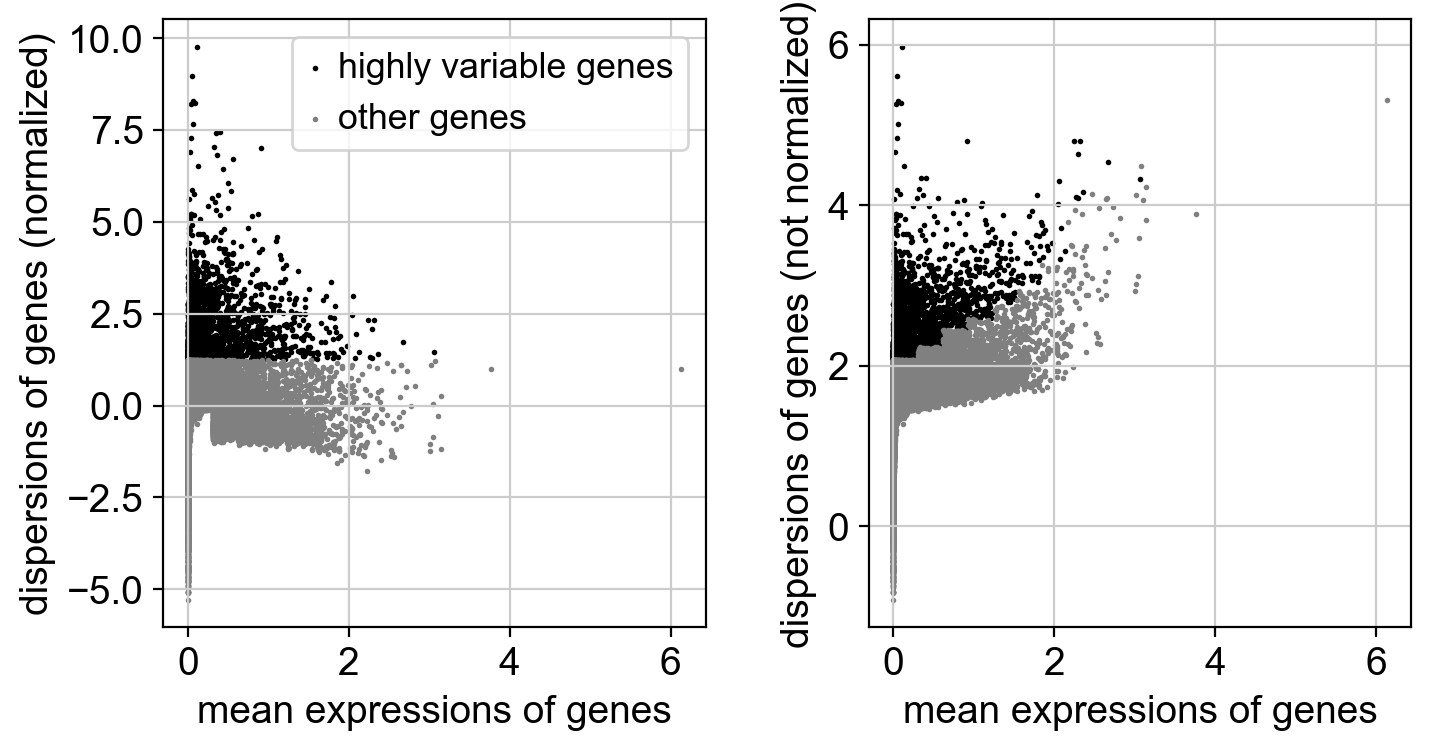


>>> HVG dispersion plot saved to ~/ATRT/Data/HVG_dispersion_plot.png


<Figure size 400x400 with 0 Axes>

In [5]:
# ============================================================
# FIGURE: Mean-dispersion plot of HVGs (supplementary)
# ============================================================

sc.pl.highly_variable_genes(adata, show=True)

plt.savefig(os.path.expanduser("~/ATRT/Data/HVG_dispersion_plot.png"), dpi=300, bbox_inches='tight')
print("\n>>> HVG dispersion plot saved to ~/ATRT/Data/HVG_dispersion_plot.png")

Cell 6 — Scale data:

In [6]:
# Scale to zero mean and unit variance, clip at 10
sc.pp.scale(adata, max_value=10)
print("Scaling complete (zero mean, unit variance, max_value=10)")

# ============================================================
# REPORT NOTE: "The count matrix was scaled to zero mean and 
# unit variance per gene prior to PCA, with maximum value 
# clipping at 10."
# ============================================================

Scaling complete (zero mean, unit variance, max_value=10)


Cell 7 — Save normalized/scaled object:

In [7]:
# Save for Program 4 (Dimensionality Reduction & Batch Correction)
output_path = os.path.expanduser("~/ATRT/Data/adata_normalized_scaled.h5ad")
adata.write(output_path)
print(f"Normalized & scaled AnnData saved to: {output_path}")
print(f"Shape: {adata.n_obs} nuclei x {adata.n_vars} genes")
print(f"HVGs: {adata.var['highly_variable'].sum()}")
print(f"Raw counts preserved in adata.raw: {adata.raw.n_vars} genes")

print(f"\n>>> Program 3 complete!")
print(f">>> Key deliverables:")
print(f">>>   - HVG dispersion plot saved")
print(f">>>   - ZMYM3 HVG status noted above")
print(f">>>   - adata_normalized_scaled.h5ad saved for Program 4")
print(f"\n>>> Next: Program 4 (PCA, Harmony Batch Correction & UMAP)")

Normalized & scaled AnnData saved to: /Users/jacquelineli/ATRT/Data/adata_normalized_scaled.h5ad
Shape: 9604 nuclei x 36601 genes
HVGs: 2000
Raw counts preserved in adata.raw: 36601 genes

>>> Program 3 complete!
>>> Key deliverables:
>>>   - HVG dispersion plot saved
>>>   - ZMYM3 HVG status noted above
>>>   - adata_normalized_scaled.h5ad saved for Program 4

>>> Next: Program 4 (PCA, Harmony Batch Correction & UMAP)
